# Лабораторная работа № 1. Классификация текстов

**Дисциплина:** Основы машинного обучения
**Направление:** Цифровая лингвистика и локализация

## Цель

Освоить базовую схему обучения с учителем на задаче, с которой лингвист
встречается в реальном проекте локализации: определить, к какому типу
контента относится сегмент текста.

## Задачи

1. Разобрать четыре шага работы с моделью в scikit-learn.
2. Построить базовое решение (baseline) и понять, зачем оно нужно.
3. Превратить текст в числовые признаки: мешок слов, TF-IDF, n-граммы.
4. Измерить качество, построить матрицу ошибок, разобрать ошибки.
5. **Главное:** выяснить, как лингвистическая предобработка влияет на
   качество, и объяснить результат свойствами русского языка.

## Что важно понять с самого начала

Модель не «понимает» текст — она видит числа. Всё, что вы как лингвист
знаете о языке, попадает в модель ровно одним способом: через то, **как вы
превратили текст в числа**. Это решение принимаете вы, а не библиотека,
и в этой работе видно, что оно влияет на результат сильнее выбора модели.

---
## 1. Данные

Учебный корпус локализации: 160 сегментов, размеченных по типу контента.

| тип | что это |
|---|---|
| `интерфейс` | строки интерфейса: кнопки, подсказки, сообщения об ошибках |
| `документация` | техническая документация, руководства |
| `маркетинг` | рекламные и продающие тексты |
| `юридический` | договоры, соглашения, политики |

Столбцы: `en` — исходный текст, `ru_ref` — эталонный перевод (работаем с ним),
`ru_mt` — машинный перевод (понадобится в Л.р. № 3).

Происхождение корпуса описано в `data/О_данных.md`. Он маленький, и это
не случайность: на нём хорошо видно, как ведёт себя модель, когда данных мало.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_colwidth", 80)

corpus = pd.read_csv("data/loc_corpus.csv")
print("Размер корпуса:", corpus.shape)
corpus.head(5)

Размер корпуса: (160, 5)


,id,type,en,ru_ref,ru_mt
0,s001,интерфейс,Save changes,Сохранить изменения,Сохранить изменения
1,s002,интерфейс,"Delete file ""{name}""?",Удалить файл «{name}»?,"Удалить файл ""(имя}""?"
2,s003,интерфейс,Sign in with your work account,Войдите с рабочей учётной записью,Подпишитесь на вашем рабочем счете
3,s004,интерфейс,Your session has expired,Срок действия сеанса истёк,Ваш сеанс закончился.
4,s005,интерфейс,Loading…,Загрузка…,Загрузка...


In [42]:
# Сбалансированность классов важно: на перекошенных данных accuracy обманывает.
corpus["type"].value_counts()

type
интерфейс       40
документация    40
маркетинг       40
юридический     40
Name: count, dtype: int64

In [43]:
# Прежде чем считать что-либо — прочитать глазами. Чем классы отличаются?
for t in corpus["type"].unique():
    print("=" * 72)
    print(t.upper())
    for s in corpus.loc[corpus["type"] == t, "ru_ref"].head(3):
        print("   ", s)

ИНТЕРФЕЙС
    Сохранить изменения
    Удалить файл «{name}»?
    Войдите с рабочей учётной записью
ДОКУМЕНТАЦИЯ
    В этом руководстве описана первоначальная настройка службы.
    Прежде чем начать, убедитесь, что у вас есть права администратора.
    Параметр задаёт максимальное число одновременных подключений.
МАРКЕТИНГ
    Работайте быстрее и спокойнее.
    Всё, что нужно вашей команде, — в одном месте.
    Попробуйте бесплатно 30 дней. Карта не нужна.
ЮРИДИЧЕСКИЙ
    Настоящие Условия регулируют использование Сервиса.
    Создавая учётную запись, вы принимаете изложенные ниже условия.
    Компания оставляет за собой право в любое время вносить изменения в настоящие Условия.


In [44]:
# Длина сегмента — характеристика, которая ещё сыграет свою роль.
corpus["слов"] = corpus["ru_ref"].str.split().str.len()
corpus.groupby("type")["слов"].agg(["mean", "min", "max"]).round(1)

,mean,min,max
type,,,
документация,7.5,5,12
интерфейс,3.1,1,7
маркетинг,5.6,3,9
юридический,7.4,4,13


Обратите внимание: строки интерфейса втрое короче документации. Запомним это —
в разделе 10 окажется, что именно они классифицируются хуже всего.

### Матрица признаков `X` и целевой вектор `y`

В scikit-learn любая задача обучения с учителем описывается двумя объектами:

* `X` — матрица признаков формы `[n_samples, n_features]`: строка — объект,
  столбец — одна измеряемая характеристика;
* `y` — целевой вектор длины `n_samples`: то, что предсказываем.

Объект у нас — сегмент текста. А признаков пока нет: текст это не число.
Их предстоит построить, и это основная работа.

In [45]:
texts  = corpus["ru_ref"]   # тексты
labels = corpus["type"]     # правильные ответы

print(texts.shape, labels.shape)

(160,) (160,)


---
## 2. Разделение на обучающую и тестовую выборки

Модель нельзя проверять на тех же данных, на которых она училась: она их
запомнила. Отложим четверть корпуса и не покажем её модели до конца работы.

`stratify=labels` сохраняет пропорции классов в обеих частях — без этого на
маленькой выборке класс может почти исчезнуть из теста.

In [46]:
from sklearn.model_selection import train_test_split

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.25,
    stratify=labels,
    random_state=0,        # фиксируем, чтобы результат воспроизводился
)

print("обучающая:", len(X_train_texts), " тестовая:", len(X_test_texts))
print(y_test.value_counts().to_dict())

обучающая: 120  тестовая: 40
{'документация': 10, 'интерфейс': 10, 'маркетинг': 10, 'юридический': 10}


---
## 3. Baseline: с чем сравнивать

Прежде чем радоваться точности, нужно знать, сколько даёт решение, вообще
не смотрящее на текст. `DummyClassifier` со стратегией `most_frequent`
всегда отвечает самым частым классом.

Классы у нас равные по размеру, поэтому baseline будет около 0.25. Любая
модель обязана его превзойти — иначе она бесполезна, какой бы сложной ни была.
Модель без baseline — это число без единиц измерения.

In [47]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
baseline = accuracy_score(y_test, dummy.predict(np.zeros((len(y_test), 1))))

print(f"Baseline (самый частый класс): {baseline:.3f}")

Baseline (самый частый класс): 0.250


---
## 4. Текст → числа: мешок слов

Простейший способ превратить текст в вектор — **мешок слов** (bag of words).
Составляем словарь всех слов корпуса; каждый текст описывается вектором,
где на месте слова стоит число его вхождений.

Порядок слов теряется полностью: «не удалось подключиться» и «удалось не
подключиться» дают одинаковый вектор. Для определения типа контента это
терпимо — тип виден по лексике. Для перевода — уже нет, и в Л.р. № 3
это будет принципиально.

In [48]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer()
X_train = vect.fit_transform(X_train_texts)   # строим словарь И преобразуем
X_test  = vect.transform(X_test_texts)        # ТОЛЬКО преобразуем

print(f"Матрица признаков: {X_train.shape[0]} текстов × {X_train.shape[1]} слов")
print("Первые 15 слов словаря:", list(vect.get_feature_names_out()[:15]))

Матрица признаков: 120 текстов × 531 слов
Первые 15 слов словаря: ['00', '02', '25', '30', '429', '60', 'api', 'csv', 'https', 'minutes', 'name', 'автоматически', 'администратора', 'администраторов', 'архива']


> **Почему `fit_transform` на обучающей, а на тестовой только `transform`?**
>
> `fit` — это обучение: здесь строится словарь. Применив `fit` к тестовой
> выборке, вы дадите модели узнать про слова, которых она видеть не должна.
> Это **утечка данных** (data leakage): оценка качества окажется завышенной,
> а в реальной работе модель поведёт себя хуже обещанного.
> Правило: `fit` — только на обучающей части.

---
## 5. Четыре шага работы с моделью

Любая модель в scikit-learn используется одинаково:

1. импортировать класс модели;
2. создать экземпляр, задав гиперпараметры;
3. обучить: `fit(X, y)`;
4. применить: `predict(X_new)`.

Начнём с наивного байесовского классификатора — того самого, на котором
работали первые спам-фильтры (см. слайд 9 лекции «Введение в машинное обучение»).

In [49]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()             # 1-2. класс и гиперпараметры
model.fit(X_train, y_train)         # 3. обучение
y_pred = model.predict(X_test)      # 4. предсказание

acc = accuracy_score(y_test, y_pred)
print(f"Мешок слов + наивный Байес: {acc:.3f}   (baseline {baseline:.3f})")

Мешок слов + наивный Байес: 0.425   (baseline 0.250)


Выше baseline, но не впечатляет. Дальше мы не будем менять модель — будем
менять признаки, и увидим, что это даёт больше.

---
## 6. TF-IDF: не все слова одинаково полезны

В мешке слов частое слово важнее редкого. Но «и», «в», «не» частотны везде и
о типе текста не говорят ничего, тогда как «Лицензиар» встречается редко и
указывает на класс почти однозначно.

**TF-IDF** взвешивает слово двумя множителями:

* **TF** (term frequency) — как часто слово встречается в этом тексте;
* **IDF** (inverse document frequency) — насколько оно редко по корпусу.

Слово, которое есть в каждом документе, получает вес около нуля.

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_t = tfidf.fit_transform(X_train_texts)
X_test_t  = tfidf.transform(X_test_texts)

model_t = MultinomialNB().fit(X_train_t, y_train)
acc_tfidf = accuracy_score(y_test, model_t.predict(X_test_t))

print(f"Мешок слов: {acc:.3f}")
print(f"TF-IDF:     {acc_tfidf:.3f}")

Мешок слов: 0.425
TF-IDF:     0.400


---
## 7. Одного разбиения мало

Тестовая выборка — 40 текстов. Пара сегментов, случайно попавших туда или
не попавших, сдвигает точность на 0.05. Делать вывод по одному разбиению нельзя.

**Кросс-валидация** делит корпус на 5 частей, обучает модель пять раз (каждый
раз одна часть — тестовая) и усредняет. Дальше все сравнения — только так,
и всегда с указанием разброса.

In [51]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

def estimate(vectorizer, classifier, X=texts, y=labels):
    '''Средняя точность по 5-кратной кросс-валидации и разброс между частями.'''
    pipe = make_pipeline(vectorizer, classifier)
    scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    return scores.mean(), scores.std()

m, s = estimate(TfidfVectorizer(), MultinomialNB())
print(f"TF-IDF + наивный Байес: {m:.3f} ± {s:.3f}")

TF-IDF + наивный Байес: 0.444 ± 0.085


> **Зачем `Pipeline`.** Он склеивает векторизацию и модель в один объект.
> Это не украшение: при кросс-валидации словарь обязан строиться заново на
> каждой обучающей части. Соберёте руками — получите утечку и завышенную оценку.

---
## 8. Предобработка текста — основная часть работы

Теперь то, ради чего работа затевалась. Модель не трогаем; меняем **способ
превращения текста в признаки**.

| что меняем | лингвистический вопрос |
|---|---|
| нижний регистр | «Сохранить» и «сохранить» — одно слово или два? |
| стоп-слова | помогает ли выбросить служебную лексику |
| биграммы | добавляет ли информацию порядок слов |
| `min_df=2` | нужны ли слова, встретившиеся ровно один раз |
| стемминг | склеятся ли словоформы одной лексемы |
| символьные n-граммы | можно ли обойтись вообще без понятия «слово» |

In [52]:
# Короткий открытый список русских стоп-слов.
# Посмотрите на него глазами лингвиста: что бы вы добавили или убрали?
STOP_WORDS = [
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то",
    "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за",
    "бы", "по", "только", "ее", "мне", "было", "вот", "от", "меня", "еще",
    "нет", "о", "из", "ему", "теперь", "когда", "даже", "ну", "вдруг", "ли",
    "если", "уже", "или", "быть", "был", "до", "вас", "опять", "уж",
    "вам", "ведь", "там", "потом", "себя", "ничего", "ей", "может", "они",
    "тут", "где", "есть", "надо", "ней", "для", "мы", "тебя", "их", "чем",
    "была", "сам", "чтоб", "без", "будто", "чего", "раз", "тоже", "себе",
    "под", "будет", "тогда", "кто", "этот", "того", "потому", "этого",
    "какой", "совсем", "ним", "здесь", "этом", "один", "почти", "мой", "тем",
    "чтобы", "нее", "были", "куда", "зачем", "всех", "никогда", "можно",
    "при", "об", "хотя", "свое", "этой", "перед", "иногда", "лучше", "эти",
]
print("стоп-слов в списке:", len(STOP_WORDS))

стоп-слов в списке: 116


In [53]:
import re
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer("russian")
TOKEN = re.compile(r"[а-яёa-z0-9]+", re.IGNORECASE)

def tokenize_words(text):
    '''Слова из букв и цифр, приведённые к нижнему регистру.'''
    return TOKEN.findall(text.lower())

def tokenize_and_stem(text):
    '''То же, но каждое слово усечено до основы.'''
    return [stemmer.stem(w) for w in tokenize_words(text)]

example = "Изменения сохранены. Сохранить настройки?"
print("без стемминга:", tokenize_words(example))
print("со стеммингом:", tokenize_and_stem(example))

без стемминга: ['изменения', 'сохранены', 'сохранить', 'настройки']
со стеммингом: ['изменен', 'сохран', 'сохран', 'настройк']


Стемминг склеил `сохранены` и `сохранить` в общую основу `сохран`. Для
русского это существеннее, чем для английского: одна лексема даёт десятки
словоформ, и без нормализации модель считает их разными, не связанными
между собой признаками. Проверим численно.

In [54]:
configs = {
    "1. TF-IDF по умолчанию":
        TfidfVectorizer(),
    "2. без нижнего регистра":
        TfidfVectorizer(lowercase=False),
    "3. со стоп-словами":
        TfidfVectorizer(stop_words=STOP_WORDS),
    "4. слова + биграммы":
        TfidfVectorizer(ngram_range=(1, 2)),
    "5. min_df=2 (без редких)":
        TfidfVectorizer(min_df=2),
    "6. стемминг":
        TfidfVectorizer(tokenizer=tokenize_and_stem, token_pattern=None),
    "7. символьные n-граммы 3-5":
        TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)),
    "8. символьные n-граммы 2-4":
        TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4)),
}

results = []
for name, vec in configs.items():
    m, s = estimate(vec, MultinomialNB())
    n_features = vec.fit(texts).transform(texts).shape[1]
    results.append({"конфигурация": name, "точность": round(m, 3),
                    "разброс": round(s, 3), "признаков": n_features})

summary = pd.DataFrame(results)
summary

,конфигурация,точность,разброс,признаков
0,1. TF-IDF по умолчанию,0.444,0.085,679
1,2. без нижнего регистра,0.419,0.064,705
2,3. со стоп-словами,0.419,0.090,637
3,4. слова + биграммы,0.456,0.076,1381
4,5. min_df=2 (без редких),0.381,0.061,99
5,6. стемминг,0.538,0.135,555
6,7. символьные n-граммы 3-5,0.631,0.098,7821
7,8. символьные n-граммы 2-4,0.612,0.102,5418


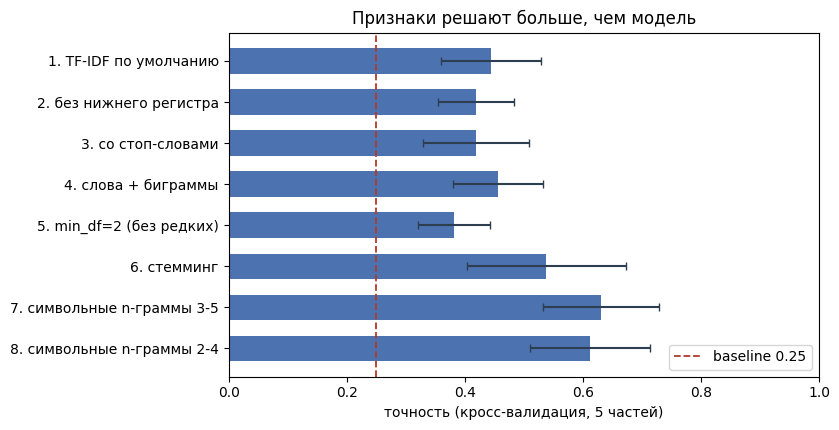

In [55]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(summary["конфигурация"], summary["точность"],
        xerr=summary["разброс"], color="#4C72B0", height=0.62,
        error_kw={"ecolor": "#2C3E50", "capsize": 3})
ax.axvline(baseline, color="#B03A2B", linestyle="--", linewidth=1.3,
           label=f"baseline {baseline:.2f}")
ax.set_xlim(0, 1.0)
ax.set_xlabel("точность (кросс-валидация, 5 частей)")
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.set_title("Признаки решают больше, чем модель")
plt.tight_layout()
plt.show()

> **Как это читать.** Чёрточка на столбце — разброс между пятью прогонами.
> Если планки двух конфигураций перекрываются, разница между ними
> **не установлена**: на 160 сегментах отличить 0.61 от 0.63 нельзя.
> Это тоже результат, и называть его нужно честно.

Что видно:

* стемминг заметно поднимает качество — русская морфология мешает мешку слов;
* символьные n-граммы поднимают ещё сильнее, хотя понятия «слово» в них нет
  вообще: подстрока `-ется` или `овор` работает как признак регистра;
* биграммы почти ничего не дают: на коротких сегментах пар слов слишком мало,
  и число признаков растёт быстрее, чем польза от них.

---
## 9. Модель тоже важна — но меньше

Единый API scikit-learn означает, что смена модели — одна строка. Возьмём
лучшую векторизацию и сравним три классификатора.

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

BEST_VECTORIZER = lambda: TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))

models = {
    "Наивный Байес":            MultinomialNB(),
    "Логистическая регрессия":  LogisticRegression(max_iter=2000),
    "Ближайшие соседи (k=5)":   KNeighborsClassifier(n_neighbors=5),
}

rows = []
for name, clf in models.items():
    m, s = estimate(BEST_VECTORIZER(), clf)
    rows.append({"модель": name, "точность": round(m, 3), "разброс": round(s, 3)})

pd.DataFrame(rows)

,модель,точность,разброс
0,Наивный Байес,0.612,0.102
1,Логистическая регрессия,0.744,0.100
2,Ближайшие соседи (k=5),0.550,0.064


Разница между моделями меньше, чем разница между способами векторизации.
Это типичная ситуация и главный практический вывод работы: **время, вложенное
в подготовку признаков, окупается лучше, чем время на подбор модели.**

> **Почему взята векторизация 2-4, если в таблице раздела 8 чуть лучше
> смотрелась 3-5?** Потому что там она оценивалась в паре с наивным Байесом,
> а здесь работает логистическая регрессия. Векторизация и модель влияют
> друг на друга, и выбирать их нужно совместно, а не по отдельности.
> Проверьте это сами: подставьте `ngram_range=(3, 5)` и сравните.

---
## 10. Матрица ошибок: что именно модель путает

Точность — одно число, и оно скрывает структуру ошибок. Матрица ошибок
показывает, какой класс с каким смешивается.

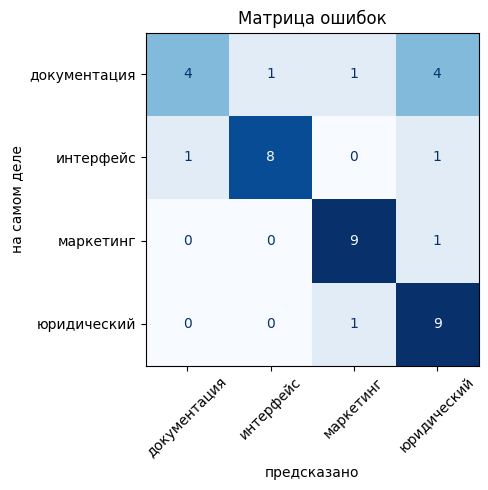

              precision    recall  f1-score   support

документация       0.80      0.40      0.53        10
   интерфейс       0.89      0.80      0.84        10
   маркетинг       0.82      0.90      0.86        10
 юридический       0.60      0.90      0.72        10

    accuracy                           0.75        40
   macro avg       0.78      0.75      0.74        40
weighted avg       0.78      0.75      0.74        40



In [57]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_pipe = make_pipeline(BEST_VECTORIZER(), LogisticRegression(max_iter=2000))
best_pipe.fit(X_train_texts, y_train)
y_pred = best_pipe.predict(X_test_texts)

fig, ax = plt.subplots(figsize=(5.6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45,
)
ax.set_xlabel("предсказано"); ax.set_ylabel("на самом деле")
ax.set_title("Матрица ошибок")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, zero_division=0))

> **precision и recall.** `precision` класса «юридический» — доля
> действительно юридических среди всех, названных юридическими.
> `recall` — доля найденных среди всех настоящих юридических.
> В локализации это разные риски: пропустить юридический сегмент
> (низкий recall) дороже, чем лишний раз отправить на проверку маркетинговый.

In [58]:
# Связь длины сегмента и качества: короткие строки интерфейса
# дают модели меньше материала.
breakdown = pd.DataFrame({
    "текст": X_test_texts, "истинный": y_test, "предсказанный": y_pred,
})
breakdown["слов"] = breakdown["текст"].str.split().str.len()
breakdown["верно"] = breakdown["истинный"] == breakdown["предсказанный"]

(breakdown.groupby("истинный")
          .agg(mean_words=("слов", "mean"), share_correct=("верно", "mean"))
          .round(2)
          .sort_values("mean_words"))

,mean_words,share_correct
истинный,,
интерфейс,2.7,0.8
маркетинг,5.7,0.9
юридический,7.8,0.9
документация,8.1,0.4


Это профессионально значимый результат: **чем короче сегмент, тем хуже
работает автоматическая классификация.** Строки интерфейса — самый
массовый тип контента в локализации и одновременно самый трудный для
любой модели, работающей с лексикой. Причина не в модели, а в том, что
в трёх словах просто мало сигнала.

---
## 11. Разбор ошибок: смотрим на сами тексты

In [59]:
errors = breakdown.loc[~breakdown["верно"], ["текст", "истинный", "предсказанный", "слов"]]
print(f"Ошибок: {len(errors)} из {len(breakdown)}")
errors

Ошибок: 10 из 40


,текст,истинный,предсказанный,слов
43,"Если значение не указано, используется значение по умолчанию.",документация,юридический,8
61,Отчёт формируется в фоновом режиме и может занять несколько минут.,документация,маркетинг,10
23,Уведомления отключены,интерфейс,юридический,2
71,Пустые значения в обязательных полях приводят к ошибке проверки.,документация,юридический,9
49,Токен доступа действителен в течение часа с момента выдачи.,документация,юридический,9
78,Часовой пояс по умолчанию — UTC.,документация,интерфейс,6
31,Перетащите файлы сюда для загрузки,интерфейс,документация,5
84,Ваши данные остаются вашими. Всегда.,маркетинг,юридический,5
150,Согласие может быть отозвано в любое время.,юридический,маркетинг,7
63,Удалённые записи остаются доступными в архиве в течение 90 дней.,документация,юридический,10


### На какие признаки опирается модель

У логистической регрессии есть веса признаков. Самые большие
положительные веса для класса — это то, по чему модель принимает решение.
Прочитайте списки как лингвист: они осмысленны?

In [60]:
vec_final = best_pipe.named_steps["tfidfvectorizer"]
clf_final = best_pipe.named_steps["logisticregression"]
features = np.array(vec_final.get_feature_names_out())

for i, cls in enumerate(clf_final.classes_):
    top = features[np.argsort(clf_final.coef_[i])[-12:]][::-1]
    print(f"{cls:>14}: {', '.join(repr(t) for t in top)}")

  документация: ' п', 'тся', 'ем', 'кат', ' пр', 'ются', 'ютс', 'ров', 'ол', 'ред', 'пр', ' в'
     интерфейс: 'ить', 'ить ', 'ит', 'ть ', 'ь ', 'ть', 'ено', 'нен', 'ено ', 'мен', ' из', 'тмен'
     маркетинг: ' б', ', ', 'жн', '. ', 'вы', 'жно', ' го', 'ры', 'ото', ' г', 'но ', ' и '
   юридический: 'нн', 'ст', 'сто', 'ны', 'тв', 'ви', 'ет', 'стор', 'х ', 'нны', 'тель', 'он'


Символьные n-граммы читаются непривычно, но узнаваемо: у юридического класса
всплывают куски `ующ`, `ени`, `сто`, характерные для канцелярских причастий
и отглагольных существительных. Модель нащупала морфологический признак
регистра, не зная ни слова о морфологии.

---
## 12. Хватает ли нам данных

Точность около 0.7 — не предел модели, а следствие размера корпуса.
**Кривая обучения** показывает, как меняется качество при росте обучающей
выборки. Если кривая на правом краю ещё поднимается, данных мало и главный
способ улучшить результат — размечать дальше, а не менять модель.

c:\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Python\Python312\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Python\Python312\Lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt, y, **last_step_pa

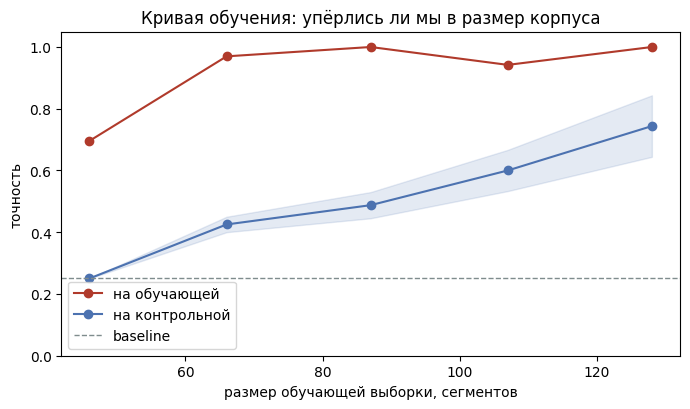

In [61]:
from sklearn.model_selection import learning_curve

sizes, train_scores, test_scores = learning_curve(
    make_pipeline(BEST_VECTORIZER(), LogisticRegression(max_iter=2000)),
    texts, labels, cv=5,
    train_sizes=np.linspace(0.2, 1.0, 6),
    scoring="accuracy",
    # Без перемешивания первая подвыборка берётся подряд, а корпус
    # отсортирован по типам — в неё попал бы один класс, и точка пропала бы.
    shuffle=True, random_state=0,
)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(sizes, train_scores.mean(axis=1), "o-", color="#B03A2B", label="на обучающей")
ax.plot(sizes, test_scores.mean(axis=1), "o-", color="#4C72B0", label="на контрольной")
ax.fill_between(sizes,
                test_scores.mean(axis=1) - test_scores.std(axis=1),
                test_scores.mean(axis=1) + test_scores.std(axis=1),
                color="#4C72B0", alpha=0.15)
ax.axhline(baseline, color="#7F8C8D", linestyle="--", linewidth=1, label="baseline")
ax.set_xlabel("размер обучающей выборки, сегментов")
ax.set_ylabel("точность")
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("Кривая обучения: упёрлись ли мы в размер корпуса")
plt.tight_layout()
plt.show()

> **Как читать кривую.** Верхняя линия — качество на данных, которые модель
> видела: она их запоминает, поэтому там почти единица. Нижняя — качество на
> новых данных, и только оно имеет смысл. Разрыв между линиями — это
> **переобучение**. Если нижняя линия к правому краю продолжает расти,
> модель ещё не насытилась данными.

---
## 13. Что реально повысит качество

Кривая обучения показала, что мы упёрлись. Но во что именно — в корпус,
в признаки или в модель? Это проверяемый вопрос, и ответ определяет, куда
тратить время. Переберём три средства и измерим каждое.

### Средство первое: подобрать гиперпараметры

Самое очевидное действие — перебрать параметры векторизатора и модели.
`GridSearchCV` обучает модель на каждой комбинации и выбирает лучшую
по кросс-валидации.

In [62]:
from sklearn.model_selection import GridSearchCV

base_score, base_std = estimate(BEST_VECTORIZER(),
                                            LogisticRegression(max_iter=2000))
print(f"исходная конфигурация: {base_score:.3f} ± {base_std:.3f}")

grid = GridSearchCV(
    make_pipeline(TfidfVectorizer(analyzer="char_wb"),
                  LogisticRegression(max_iter=3000)),
    param_grid={
        "tfidfvectorizer__ngram_range":  [(2, 4), (2, 5), (3, 5), (1, 4)],
        "tfidfvectorizer__sublinear_tf": [False, True],
        "tfidfvectorizer__min_df":       [1, 2],
        "logisticregression__C":         [1.0, 5.0, 20.0],
    },
    cv=5, scoring="accuracy", n_jobs=-1,
)
grid.fit(texts, labels)

print(f"после перебора 48 комбинаций: {grid.best_score_:.3f}")
print(f"прирост: {grid.best_score_ - base_score:+.3f}")
print("лучшие параметры:",
      {k.split("__")[-1]: v for k, v in grid.best_params_.items()})

исходная конфигурация: 0.744 ± 0.100
после перебора 48 комбинаций: 0.744
прирост: +0.000
лучшие параметры: {'C': 1.0, 'min_df': 1, 'ngram_range': (2, 4), 'sublinear_tf': False}


> **Прирост нулевой.** Значения по умолчанию уже оказались оптимальными.
> Это типичный результат, о котором редко пишут: перебор гиперпараметров
> окупается, когда данных много, а модель сложная. На маленьком корпусе он
> находит ровно то, с чего вы начали, — и съедает время, которое можно было
> потратить на разметку.

### Средство второе: объединить разные признаки

Словарные признаки видят лексику, символьные — морфологию. Логично
предположить, что вместе они дадут больше, чем по отдельности.
`FeatureUnion` считает оба набора и склеивает их в одну матрицу.

In [63]:
from sklearn.pipeline import make_union

union = make_union(
    TfidfVectorizer(tokenizer=tokenize_and_stem, token_pattern=None),
    TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4)),
)
m_union, s_union = estimate(union, LogisticRegression(max_iter=2000))

print(f"только символьные:      {base_score:.3f} ± {base_std:.3f}")
print(f"словарные + символьные: {m_union:.3f} ± {s_union:.3f}")
print(f"прирост: {m_union - base_score:+.3f}")

только символьные:      0.744 ± 0.100
словарные + символьные: 0.725 ± 0.116
прирост: -0.019


> **Прирост отрицательный.** Словарные признаки не добавили информации, зато
> добавили шума: их в несколько раз больше, и на 160 примерах модель начинает
> подстраиваться под случайные совпадения. Больше признаков — не значит лучше,
> когда примеров мало.

### Средство третье: больше данных

Осталось проверить единственное, чего мы ещё не пробовали. Своего корпуса
больше нет, поэтому возьмём **реальный набор данных** — коллекцию сообщений
из групп новостей, стандартный учебный корпус для классификации текстов.
Задача та же: четыре класса, определить тему по тексту. Векторизация и
модель — ровно наши.

Это позволяет ответить честно: дело в методе или в объёме?

In [64]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import learning_curve

categories = ["rec.autos", "sci.med", "talk.politics.guns", "comp.graphics"]

try:
    news = fetch_20newsgroups(
        subset="train", categories=categories,
        remove=("headers", "footers", "quotes"), random_state=0,
    )
    print(f"загружено: {len(news.data)} документов, {len(categories)} класса")

    sizes_big, _, test_scores = learning_curve(
        make_pipeline(TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4)),
                      LogisticRegression(max_iter=2000)),
        news.data, news.target, cv=5,
        train_sizes=[160, 320, 640, 1280, 1800],
        scoring="accuracy", n_jobs=-1,
    )
    growth_table = pd.DataFrame({
        "обучающих примеров": sizes_big.astype(int),
        "точность": test_scores.mean(axis=1).round(3),
    })
    print(growth_table.to_string(index=False))
except Exception as e:
    growth_table = None
    print("Набор данных загрузить не удалось:", type(e).__name__)
    print("При первом запуске нужен доступ к сети (около 14 МБ);")
    print("дальше он берётся из локального кэша. Раздел необязательный.")

загружено: 2318 документов, 4 класса
 обучающих примеров  точность
                160     0.546
                320     0.732
                640     0.786
               1280     0.821
               1800     0.830


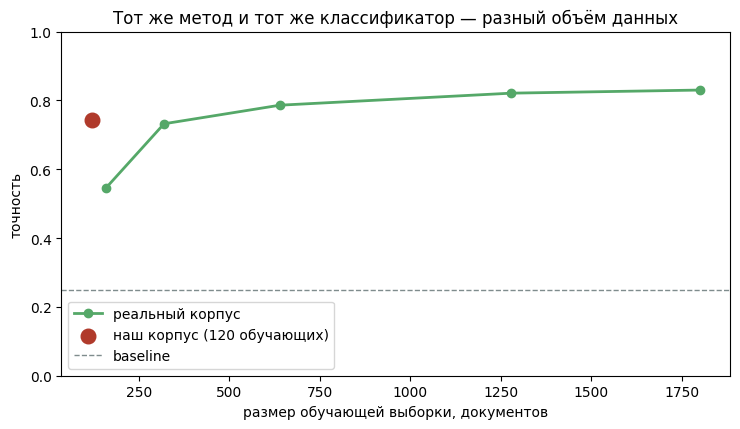

In [65]:
if growth_table is not None:
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    ax.plot(growth_table["обучающих примеров"], growth_table["точность"],
            "o-", color="#55A868", linewidth=2, label="реальный корпус")
    ax.scatter([120], [base_score], s=110, color="#B03A2B", zorder=5,
               label="наш корпус (120 обучающих)")
    ax.axhline(baseline, color="#7F8C8D", linestyle="--", linewidth=1,
               label="baseline")
    ax.set_xlabel("размер обучающей выборки, документов")
    ax.set_ylabel("точность")
    ax.set_ylim(0, 1.0)
    ax.legend()
    ax.set_title("Тот же метод и тот же классификатор — разный объём данных")
    plt.tight_layout()
    plt.show()

> **Вот и ответ.** На 160 примерах тот же самый метод даёт около 0.55, на
> 1800 — около 0.83. Метод ни при чём: **упёрлись мы в размер корпуса.**
>
> Наш результат (около 0.75 на 120 обучающих сегментах) даже выше — потому
> что наши классы различаются резче, чем темы новостных групп. Но потолок
> по природе тот же.

### Сводка: куда тратить время

| средство | прирост | вывод |
|---|---|---|
| подбор гиперпараметров | около нуля | значения по умолчанию уже хороши |
| объединение признаков | отрицательный | больше признаков при малой выборке вредит |
| **больше размеченных данных** | **+0.28 на реальном корпусе** | **единственное, что работает** |

Это главный практический вывод курса, и он не про программирование:
**размеченные данные — самый дефицитный ресурс в машинном обучении.**
Разметка — работа лингвиста, и платят за неё не за нажатие кнопок,
а за то, что без неё модель не построить вообще.

---
## Задание

1. **Изучите ноутбук** и выполните его сверху вниз без ошибок.

2. **Расширьте таблицу предобработки** (раздел 8) минимум тремя своими
   конфигурациями. Например: только биграммы `ngram_range=(2, 2)`;
   символьные n-граммы других длин; стемминг вместе с `min_df=2`;
   `sublinear_tf=True`. Для каждой укажите точность, разброс и число признаков.

3. **Ответьте на главный вопрос работы:** какая предобработка дала прирост,
   какая нет, и почему. Ответ — не «стемминг лучше», а объяснение через
   свойства русского языка и через число признаков в таблице.

4. **Разберите все ошибки** вашей лучшей конфигурации (раздел 11). Для каждого
   ошибочно классифицированного сегмента напишите, какая лексика или какой
   регистр увели модель не туда.

5. **Проверьте границы применимости.** Повторите разделы 8-9 на столбце `en`
   вместо `ru_ref`. Стемминг для английского даёт тот же эффект, что для
   русского? Символьные n-граммы? Объясните разницу — это вопрос про
   типологию языков, а не про программирование.

6. **Оцените, чего не хватает.** По кривой обучения (раздел 12) скажите:
   упёрлась ли модель в размер корпуса? Сколько примерно сегментов нужно
   разметить, чтобы точность выросла ещё на 0.05? Обоснуйте оценку.

7. **Проверьте вывод раздела 13 на своих параметрах.** Расширьте сетку
   `GridSearchCV` тремя своими. Удалось ли получить прирост больше 0.02?
   Если нет — укажите, сколько времени занял перебор и что можно было
   сделать за это время вместо него.

8. **Оцените стоимость разметки.** По графику раздела 13 определите, сколько
   документов нужно разметить, чтобы поднять точность до 0.85. Считая
   скорость разметки 60 сегментов в час, оцените трудоёмкость в часах и
   сравните с временем из задания 7.

9. **Сформулируйте вывод**, в котором обязательно названы: точность baseline,
   точность лучшей конфигурации, разброс, и честный ответ на вопрос,
   значима ли разница между двумя вашими лучшими конфигурациями.

### Требования к отчёту

* ноутбук выполняется сверху вниз на чистом окружении;
* каждая таблица и каждый график сопровождаются текстовым выводом;
* слова «хорошо» и «плохо» не используются без числа рядом;
* отрицательный результат («предобработка не помогла») — полноценный
  результат, если он объяснён.